# Dataset Calibration and Threat-Model Grounding

**Author:** Oyinlayefa  
**Institution:** University of The West of England Bristol  
**Date:** July 2026  

*A Strategic Framework and Technical Artefact for Secure Big Data Ingestion of Ambient IoT in Cloud-Native Environments*.

This notebook has two aims:

1. **Calibration:** compare environmental assumptions in the simulator with real greenhouse telemetry.
2. **Threat-model grounding:** assess whether attacks can be distinguished from normal IoT weather telemetry by temperature values alone.

## Required data
| File | Source | Conditions of use |
|---|---|---|
| `IoTProcessed_Data.csv` | https://www.kaggle.com/datasets/wisam1985/iot-agriculture-2024 | Attribution required; dataset must not be altered |
| `Train_Test_IoT_Weather.csv` | https://research.unsw.edu.au/projects/toniot-datasets | Free academic use granted in perpetuity; all eight papers nominated by UNSW Canberra must be cited |

Both datasets are read without modification and are not redistributed with this repository.

Accessed: *4th June 2026*

Place these files in a `data/` directory alongside this notebook:



The source temperature field in the greenhouse CSV is named `tempreature`; the spelling is retained because the original file is read without modification.

## 1. Setup

In [1]:
import json # Used for JSON file operations
from pathlib import Path # Used for path manipulations

import matplotlib.pyplot as plt # Used for plotting
import numpy as np # Used for numerical operations
import pandas as pd # Used for data manipulation and analysis
from scipy import stats # Used for statistical functions, specifically t-tests

# Define data and output directories
DATA_DIR = Path("data")
OUTPUT_DIR = Path("output")
OUTPUT_DIR.mkdir(exist_ok=True) # Create output directory if it doesn't exist

# Set pandas display options for better DataFrame readability
pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 20)

# Parameters used by the simulator under evaluation.
SIM_BASE_TEMPS = (20.0, 22.0) # Base temperature range for the simulator
SIM_AMPLITUDE_C = 3.5 # Amplitude of temperature variation in the simulator (°C)
SIM_BAND = (18.0, 26.0) # Operating temperature band for the simulator (°C)

print(f"pandas version: {pd.__version__}")

pandas version: 2.2.3


## 2. Load and validate data

In [2]:
tikrit_path = DATA_DIR / "IoTProcessed_Data.csv" # Path to the Tikrit greenhouse dataset
ton_path = DATA_DIR / "Train_Test_IoT_Weather.csv" # Path to the ToN_IoT dataset

# Check if required dataset files are missing and raise an error if they are
missing_files = [str(path) for path in (tikrit_path, ton_path) if not path.exists()]
if missing_files:
    raise FileNotFoundError(
        "Missing required dataset file(s): " + ", ".join(missing_files) +
        ". Put both CSV files inside the data/ directory."
    )

# Load the datasets into pandas DataFrames
tikrit = pd.read_csv(tikrit_path, parse_dates=["date"]) # Parse 'date' column as datetime objects
ton = pd.read_csv(ton_path, encoding="utf-8-sig") # Load ToN_IoT dataset

# Define required columns for each dataset
required_tikrit = {"date", "tempreature"}
required_ton = {"temperature", "label", "type"}

# Check if any required columns are missing in Tikrit dataset
if missing := required_tikrit.difference(tikrit.columns):
    raise KeyError(f"Tikrit dataset is missing: {sorted(missing)}")
# Check if any required columns are missing in ToN_IoT dataset
if missing := required_ton.difference(ton.columns):
    raise KeyError(f"ToN_IoT dataset is missing: {sorted(missing)}")

# Print summary information for each dataset
print(f"Tikrit greenhouse records: {len(tikrit):,}")
print(f"Tikrit date span: {tikrit['date'].min()} to {tikrit['date'].max()}")
print(f"ToN_IoT records: {len(ton):,}")

# Display the first few rows of each DataFrame
display(tikrit.head())
display(ton.head())

Tikrit greenhouse records: 37,922
Tikrit date span: 2023-11-27 06:26:00 to 2024-03-30 05:24:00
ToN_IoT records: 39,260


,date,tempreature,humidity,water_level,N,P,K,Fan_actuator_OFF,Fan_actuator_ON,Watering_plant_pump_OFF,Watering_plant_pump_ON,Water_pump_actuator_OFF,Water_pump_actuator_ON
0,2024-02-08 06:10:00,41,63,100,255,255,255,0.0,1.0,1.0,0.0,1.0,0.0
1,2024-02-08 06:15:00,41,59,100,255,255,255,0.0,1.0,1.0,0.0,1.0,0.0
2,2024-02-08 06:20:00,41,62,100,255,255,255,0.0,1.0,1.0,0.0,1.0,0.0
3,2024-02-08 06:05:00,40,60,100,255,255,255,0.0,1.0,1.0,0.0,1.0,0.0
4,2024-02-08 06:00:00,39,61,100,255,255,255,0.0,1.0,1.0,0.0,1.0,0.0


,date,time,temperature,pressure,humidity,label,type
0,25-Apr-19,17:33:16,40.881866,-0.101806,38.363631,1,ddos
1,25-Apr-19,17:33:16,44.913806,2.661616,46.141423,1,ddos
2,25-Apr-19,17:33:16,38.295822,-2.438871,50.850643,1,ddos
3,25-Apr-19,17:33:21,41.306586,-0.101806,38.363631,1,ddos
4,25-Apr-19,17:33:21,44.903178,3.080849,46.141423,1,ddos


## 3. Greenhouse calibration

This section evaluates whether the simulator’s baseline temperature, daily variation, operating band, and sampling assumptions resemble the observed greenhouse deployment.

### 3.1 Temperature and sampling summary

In [3]:
temp = tikrit["tempreature"] # Extract the 'tempreature' column for analysis
intervals = tikrit["date"].sort_values().diff().dropna() # Calculate time differences between consecutive readings to find sampling intervals

# Create a DataFrame to summarize central tendency and other metrics
central_tendency = pd.DataFrame({
    "Metric": [
        "Records", "Mean temperature (°C)", "Median temperature (°C)",
        "Standard deviation (°C)", "Minimum (°C)", "Maximum (°C)",
        "5th percentile (°C)", "95th percentile (°C)", "Modal sampling interval"
    ],
    "Observed value": [
        len(tikrit), temp.mean(), temp.median(), temp.std(), temp.min(), temp.max(),
        temp.quantile(0.05), temp.quantile(0.95), str(intervals.mode().iloc[0])
    ]
})

# Round numerical values in the 'Observed value' column for better presentation
central_tendency.iloc[1:8, 1] = central_tendency.iloc[1:8, 1].astype(float).round(2)
display(central_tendency)

,Metric,Observed value
0,Records,37922
1,Mean temperature (°C),18.76
2,Median temperature (°C),17.0
3,Standard deviation (°C),7.14
4,Minimum (°C),3.0
5,Maximum (°C),41.0
6,5th percentile (°C),10.0
7,95th percentile (°C),31.0
8,Modal sampling interval,0 days 00:05:00


### 3.2 Daily and hourly variation

In [4]:
tikrit = tikrit.copy() # Create a copy to avoid SettingWithCopyWarning
tikrit["day"] = tikrit["date"].dt.date # Extract the date part from the 'date' column
tikrit["hour"] = tikrit["date"].dt.hour # Extract the hour part from the 'date' column

# Group by day to calculate daily min, max, and mean temperatures
daily = tikrit.groupby("day")["tempreature"].agg(min="min", max="max", mean="mean")
daily["swing"] = daily["max"] - daily["min"] # Calculate daily temperature swing

# Group by hour to calculate mean hourly temperatures
hourly = tikrit.groupby("hour")["tempreature"].mean()
observed_amplitude = (hourly.max() - hourly.min()) / 2 # Calculate observed sine-equivalent amplitude

# Create a DataFrame to summarize daily and hourly variation metrics
variation_summary = pd.DataFrame({
    "Metric": [
        "Mean daily peak-to-trough swing (°C)",
        "Median daily peak-to-trough swing (°C)",
        "Mean of daily means (°C)",
        "Lowest hourly mean (°C)",
        "Hour of lowest hourly mean",
        "Highest hourly mean (°C)",
        "Hour of highest hourly mean",
        "Observed sine-equivalent amplitude (°C)",
        "Simulator amplitude (°C)",
        "Observed / simulated amplitude ratio"
    ],
    "Observed value": [
        daily["swing"].mean(), daily["swing"].median(), daily["mean"].mean(),
        hourly.min(), int(hourly.idxmin()), hourly.max(), int(hourly.idxmax()),
        observed_amplitude, SIM_AMPLITUDE_C, observed_amplitude / SIM_AMPLITUDE_C
    ]
})
# Round numerical values in the 'Observed value' column for better presentation
variation_summary.iloc[[0, 1, 2, 3, 5, 7, 8, 9], 1] = (
    variation_summary.iloc[[0, 1, 2, 3, 5, 7, 8, 9], 1].astype(float).round(2)
)
display(variation_summary)

,Metric,Observed value
0,Mean daily peak-to-trough swing (°C),18.47
1,Median daily peak-to-trough swing (°C),20.00
2,Mean of daily means (°C),18.92
3,Lowest hourly mean (°C),11.21
4,Hour of lowest hourly mean,21.00
5,Highest hourly mean (°C),28.64
6,Hour of highest hourly mean,5.00
7,Observed sine-equivalent amplitude (°C),8.72
8,Simulator amplitude (°C),3.50
9,Observed / simulated amplitude ratio,2.49


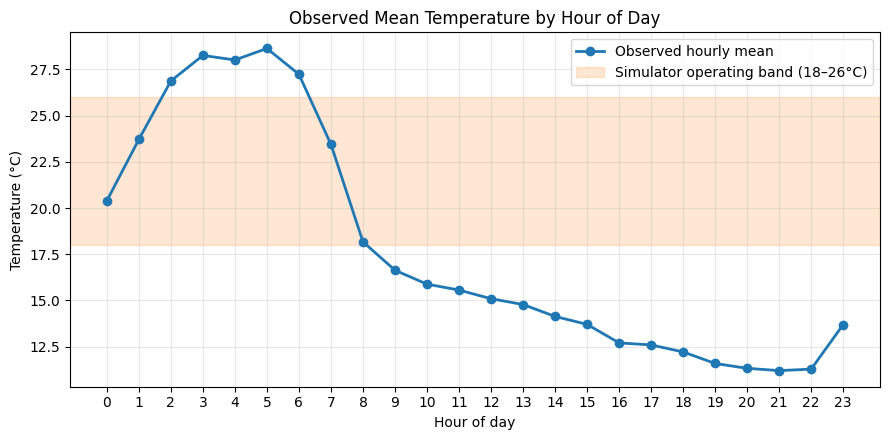

In [5]:
from pathlib import Path
OUTPUT_DIR = Path("output")
OUTPUT_DIR.mkdir(exist_ok=True)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(hourly.index, hourly.values, marker="o", linewidth=2, label="Observed hourly mean")
ax.axhspan(*SIM_BAND, color="tab:orange", alpha=0.18, label=f"Simulator operating band ({SIM_BAND[0]:.0f}–{SIM_BAND[1]:.0f}°C)")
ax.set(xlabel="Hour of day", ylabel="Temperature (°C)", title="Observed Mean Temperature by Hour of Day")
ax.set_xticks(range(24))
ax.grid(alpha=0.3)
ax.legend()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "tikrit_hourly_profile.png", dpi=200)
plt.show()

**Note on phase.** The profile peaks in the early morning and troughs in the evening,
inverted relative to solar forcing. The 48-hour trace below shows a smooth cycle of roughly
30°C amplitude whose shape is characteristic of solar gain rather than thermostat cycling,
which would produce flat plateaus and sawtooth edges. The most likely explanation is
therefore an offset between the logging timestamps and local time rather than heating-cycle
control. Phase is not used in the calibration, which compares amplitude and band occupancy;
the profile should not be read as a natural diurnal cycle.

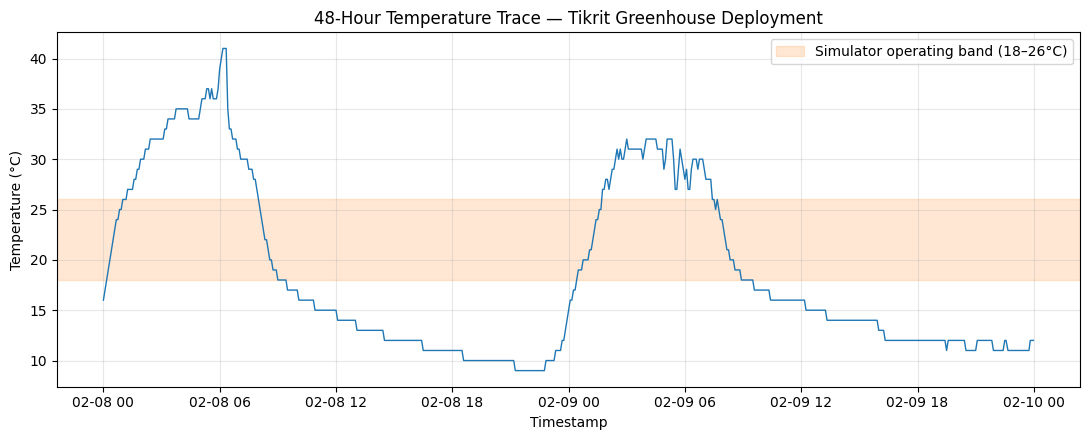

In [6]:
from pathlib import Path
OUTPUT_DIR = Path("output")
OUTPUT_DIR.mkdir(exist_ok=True)

window = tikrit[(tikrit["date"] >= "2024-02-08") & (tikrit["date"] < "2024-02-10")].sort_values("date")
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(window["date"], window["tempreature"], linewidth=1)
ax.axhspan(*SIM_BAND, color="tab:orange", alpha=0.18, label=f"Simulator operating band ({SIM_BAND[0]:.0f}–{SIM_BAND[1]:.0f}°C)")
ax.set(xlabel="Timestamp", ylabel="Temperature (°C)", title="48-Hour Temperature Trace — Tikrit Greenhouse Deployment")
ax.grid(alpha=0.3)
ax.legend()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "tikrit_48h_trace.png", dpi=200)
plt.show()

### 3.3 Operating-band comparison

In [7]:
in_band = temp.between(*SIM_BAND).mean() * 100 # Calculate percentage of readings within the simulator's operating band
below_band = (temp < SIM_BAND[0]).mean() * 100 # Calculate percentage of readings below the simulator's operating band
above_band = (temp > SIM_BAND[1]).mean() * 100 # Calculate percentage of readings above the simulator's operating band

# Create a DataFrame to summarize calibration parameters
calibration_summary = pd.DataFrame([
    {
        "Parameter": "Mean / base temperature",
        "Simulator": f"{SIM_BASE_TEMPS[0]:.1f}–{SIM_BASE_TEMPS[1]:.1f}°C",
        "Observed": f"{temp.mean():.2f}°C"
    },
    {
        "Parameter": "Diurnal amplitude",
        "Simulator": f"{SIM_AMPLITUDE_C:.2f}°C",
        "Observed": f"{observed_amplitude:.2f}°C"
    },
    {
        "Parameter": "Observed temperature range",
        "Simulator": "Configured scenario values",
        "Observed": f"{temp.min():.0f}–{temp.max():.0f}°C"
    },
    {
        "Parameter": f"Readings inside {SIM_BAND[0]:.0f}–{SIM_BAND[1]:.0f}°C band",
        "Simulator": "Defined operating band",
        "Observed": f"{in_band:.1f}%"
    },
    {
        "Parameter": "Sampling interval",
        "Simulator": "5 minutes (dimensional generator)",
        "Observed": str(intervals.mode().iloc[0])
    }
])
display(calibration_summary)

# Create a DataFrame to summarize temperature readings based on simulator band
band_summary = pd.DataFrame({
    "Temperature category": [
        f"Below {SIM_BAND[0]:.0f}°C", f"Within {SIM_BAND[0]:.0f}–{SIM_BAND[1]:.0f}°C", f"Above {SIM_BAND[1]:.0f}°C"
    ],
    "Readings (%)": [below_band, in_band, above_band]
})
band_summary["Readings (%)"] = band_summary["Readings (%)"].round(1) # Round percentages
display(band_summary)

,Parameter,Simulator,Observed
0,Mean / base temperature,20.0–22.0°C,18.76°C
1,Diurnal amplitude,3.50°C,8.72°C
2,Observed temperature range,Configured scenario values,3–41°C
3,Readings inside 18–26°C band,Defined operating band,24.9%
4,Sampling interval,5 minutes (dimensional generator),0 days 00:05:00


,Temperature category,Readings (%)
0,Below 18°C,53.8
1,Within 18–26°C,24.9
2,Above 26°C,21.2


### 3.4 Interpretation

Three of the four simulator parameters are corroborated. The observed mean of 18.76°C sits
just below the configured zone baselines of 20.0°C and 22.0°C, a difference of roughly one
to three degrees against an observed standard deviation of 7.14°C. The modal sampling
interval of five minutes matches the interval used by the dimensional dataset generator
exactly. The observed range of 3°C to 41°C is wide enough to support the engineered anomaly
windows in the generator as a realistic operational phenomenon rather than an artificial
convenience: excursions of that magnitude occur in a real deployment.

The fourth parameter diverges, and the divergence is a modelling decision rather than a
defect. The observed sine-equivalent amplitude of 8.72°C is 2.49 times the simulator's
3.50°C, and only 24.9 per cent of observed readings fall inside the 18–26°C band the model
assumes, with 53.8 per cent below it. The two deployments are not the same kind of facility.
The artefact models a climate-controlled environment in which active heating, ventilation
and shading damp the daily swing; the Tikrit installation is passively heated and its
temperature is dominated by actuator cycles, which is visible in the source data's fan and
irrigation state columns and in the inverted phase noted above. A model of a controlled
facility that reproduced an 8.72°C swing would be modelling the wrong thing.

The calibration therefore supports the simulator's central tendency and sampling behaviour,
and establishes that its damped amplitude is a deliberate representation of a different
deployment class. It does not claim the simulator reproduces the Tikrit greenhouse.

## 4. ToN_IoT threat-model grounding

This section tests whether normal and attack periods differ enough in **temperature values alone** to justify value-based filtering at an edge gateway.

**How the labels were produced.** UNSW Canberra labelled records by tagging attacker IP
addresses (192.168.159.30–39) and the timestamps of their activity, with Kali Linux hosts used to
attack cloud gateways, MQTT brokers, Node-RED applications and network services. A record
labelled `1` therefore indicates that the reading was taken *while the deployment was under
attack*; it does not indicate that the reading itself was altered. This distinction constrains what
the analysis below can be claimed to show.

### 4.1 Dataset composition

In [8]:
label_distribution = (
    ton["label"].map({0: "Normal", 1: "Attack"})
    .value_counts()
    .rename_axis("Period")
    .reset_index(name="Records")
)

attack_distribution = (
    ton["type"]
    .value_counts()
    .rename_axis("Attack type")
    .reset_index(name="Records")
)

display(label_distribution)
display(attack_distribution)

,Period,Records
0,Attack,24260
1,Normal,15000


,Attack type,Records
0,normal,15000
1,ddos,5000
2,backdoor,5000
3,injection,5000
4,password,5000
5,ransomware,2865
6,xss,866
7,scanning,529


### 4.2 Normal-versus-attack comparison

In [9]:
normal = ton.loc[ton["label"] == 0, "temperature"].dropna() # Filter for normal temperature readings, dropping any NaN values
attack = ton.loc[ton["label"] == 1, "temperature"].dropna() # Filter for attack period temperature readings
injection = ton.loc[ton["type"] == "injection", "temperature"].dropna() # Filter specifically for injection attack temperature readings

# Create a summary DataFrame for telemetry statistics (n, mean, sd, min, max)
telemetry_summary = pd.DataFrame({
    "n": [len(normal), len(attack), len(injection)],
    "mean": [normal.mean(), attack.mean(), injection.mean()],
    "sd": [normal.std(), attack.std(), injection.std()],
    "min": [normal.min(), attack.min(), injection.min()],
    "max": [normal.max(), attack.max(), injection.max()]
}, index=["Normal", "All attack periods", "Injection only"]).round(2)

display(telemetry_summary)

,n,mean,sd,min,max
Normal,15000,35.11,8.73,20.53,49.98
All attack periods,24260,35.33,7.48,20.54,49.45
Injection only,5000,36.31,7.67,20.59,49.45


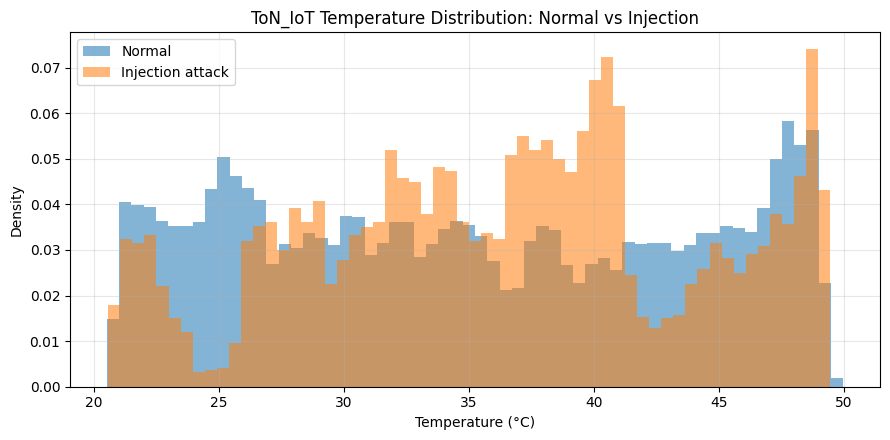

In [10]:
from pathlib import Path
OUTPUT_DIR = Path("output")
OUTPUT_DIR.mkdir(exist_ok=True)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(normal, bins=60, alpha=0.55, density=True, label="Normal")
ax.hist(injection, bins=60, alpha=0.55, density=True, label="Injection attack")
ax.set(xlabel="Temperature (°C)", ylabel="Density", title="ToN_IoT Temperature Distribution: Normal vs Injection")
ax.grid(alpha=0.3)
ax.legend()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "ton_iot_distribution_comparison.png", dpi=200)
plt.show()

### 4.3 Effect size and range overlap

In [11]:
def compare_groups(reference, comparison, name):
    """Compares two groups using Welch's t-test and calculates Cohen's d and range overlap."""
    t_stat, p_value = stats.ttest_ind(reference, comparison, equal_var=False) # Perform Welch's t-test (assumes unequal variances)
    pooled_sd = np.sqrt((reference.std() ** 2 + comparison.std() ** 2) / 2) # Calculate pooled standard deviation
    cohens_d = (comparison.mean() - reference.mean()) / pooled_sd # Calculate Cohen's d effect size
    return {
        "Comparison": name,
        "Welch t": t_stat,
        "p value": p_value,
        "Cohen's d": cohens_d,
        "Range overlap (°C)": (
            f"{max(reference.min(), comparison.min()):.2f}–" # Calculate the start of the overlap range
            f"{min(reference.max(), comparison.max()):.2f}" # Calculate the end of the overlap range
        )
    }

# Perform comparisons between normal and attack periods, and normal and injection periods
comparison_results = pd.DataFrame([
    compare_groups(normal, attack, "Normal vs all attack periods"),
    compare_groups(normal, injection, "Normal vs injection periods")
])
# Round numerical results for better presentation
comparison_results[["Welch t", "p value", "Cohen's d"]] = (
    comparison_results[["Welch t", "p value", "Cohen's d"]].round(4)
)
display(comparison_results)

,Comparison,Welch t,p value,Cohen's d,Range overlap (°C)
0,Normal vs all attack periods,-2.5721,0.0101,0.0272,20.54–49.45
1,Normal vs injection periods,-9.3025,0.0000,0.1469,20.59–49.45


### 4.4 Interpretation

Temperature values alone do not separate attack periods from normal operation. The mean
difference between the two groups is 0.22°C against standard deviations above seven, giving
a Cohen's d of 0.027 — an effect size conventionally described as negligible. Restricting the
comparison to injection attacks, the class most likely to alter readings, raises the effect
size only to 0.147, still below the 0.2 threshold for a small effect. The observed ranges
overlap almost entirely, from 20.5°C to 49.5°C in both groups.

Both differences are statistically significant, at p = 0.0101 and p < 0.0001 respectively.
That significance is a function of sample size rather than of practical separability: with
39,260 records, a Welch test will detect a difference of a fifth of a degree. Significance
and discriminability are not the same property, and only the second is useful to a filter.

The implication for the artefact is direct. A value-based anomaly filter placed at the
ingestion layer would have no reliable signal on which to act, because the distributions it
would need to separate are effectively identical. Rejection must therefore be decided on
*who is transmitting* rather than on *what is being transmitted*, which is what the edge
gateway's MAC verification does, and it must be decided before the message is admitted,
since detection after admission has already consumed broker capacity, a function invocation
and a database write.

Two limits bound what this analysis establishes. UNSW Canberra labelled records by attacker
IP address and activity timestamp, so a label of `1` means the reading was captured while the
deployment was under attack, not that the reading itself was manipulated. The absence of a
temperature signal is therefore consistent with two explanations: that the attacks did not
alter sensor values, or that they altered them within the normal operating range. Either
supports the same conclusion for this artefact, since both leave a value-based filter with
nothing to detect. Second, this analysis considers temperature in isolation. Classifiers
trained on the full ToN_IoT feature set achieve considerably higher accuracy, but they do so
by learning the correlates of a compromised deployment — network conditions, host behaviour,
timing — rather than implausible measurements. A spoofed ambient tag publishing well-formed
values into an otherwise healthy system presents no such correlates.

This matters for the artefact's own evaluation. The rogue, spoofed and tampered packets in
`test_auth_bridge.py` were constructed by the same codebase that rejects them, so a 100 per
cent rejection rate demonstrates that the mechanism functions as specified — it cannot
establish that identity-based rejection is *necessary*. The external grounding for that claim
comes from this dataset, not from the artefact's own tests.

## 5. Export reproducibility evidence

The following cell writes the principal figures used in the notebook to a machine-readable JSON record. The figures are also saved in the `output/` folder.

In [12]:
import json, numpy as np, pandas as pd
from scipy import stats
from pathlib import Path # Used for path manipulations

# Define output directory (re-defined for self-containment)
OUTPUT_DIR = Path("output")
OUTPUT_DIR.mkdir(exist_ok=True) # Create output directory if it doesn't exist

# --- Start of self-contained stats_block calculation (for ToN_IoT) ---
# Re-read data for independent calculation of threat model stats to ensure accuracy.
w_ton = pd.read_csv("data/Train_Test_IoT_Weather.csv")
temp_ton = pd.to_numeric(w_ton["temperature"], errors="coerce")

normal_ton    = temp_ton[w_ton["label"] == 0].dropna()
attack_ton    = temp_ton[w_ton["label"] == 1].dropna()
injection_ton = temp_ton[w_ton["type"] == "injection"].dropna()

def cohens_d_calc(a, b):
    pooled = np.sqrt((a.std() ** 2 + b.std() ** 2) / 2)
    if pooled == 0:
        return 0.0
    return float((b.mean() - a.mean()) / pooled)

t1_ton, p1_ton = stats.ttest_ind(normal_ton, attack_ton,    equal_var=False)
t2_ton, p2_ton = stats.ttest_ind(normal_ton, injection_ton, equal_var=False)

stats_block = {
    "normal_vs_attack_cohens_d":    round(abs(cohens_d_calc(normal_ton, attack_ton)), 4),
    "normal_vs_injection_cohens_d": round(abs(cohens_d_calc(normal_ton, injection_ton)), 4),
    "normal_vs_attack_p_value":     round(float(p1_ton), 4),
    "normal_vs_injection_p_value":  float(p2_ton),
}
# --- End of self-contained stats_block calculation ---

# --- Start of self-contained tikrit_calibration calculation ---
# Re-read data and re-calculate variables for Tikrit calibration
tikrit = pd.read_csv("data/IoTProcessed_Data.csv", parse_dates=["date"]) # Re-load Tikrit dataset
temp = tikrit["tempreature"] # Extract the 'tempreature' column for analysis
intervals = tikrit["date"].sort_values().diff().dropna() # Calculate time differences between consecutive readings

# Simulator parameters (re-defined for self-containment)
SIM_AMPLITUDE_C = 3.5 # Amplitude of temperature variation in the simulator (°C)
SIM_BAND = (18.0, 26.0) # Operating temperature band for the simulator (°C)

# Daily and hourly variation calculations
tikrit_copy = tikrit.copy()
tikrit_copy["day"] = tikrit_copy["date"].dt.date
tikrit_copy["hour"] = tikrit_copy["date"].dt.hour
daily = tikrit_copy.groupby("day")["tempreature"].agg(min="min", max="max", mean="mean")
daily["swing"] = daily["max"] - daily["min"] # Calculate daily temperature swing
hourly = tikrit_copy.groupby("hour")["tempreature"].mean()
observed_amplitude = (hourly.max() - hourly.min()) / 2

# Operating-band comparison calculations
in_band = temp.between(*SIM_BAND).mean() * 100
below_band = (temp < SIM_BAND[0]).mean() * 100
above_band = (temp > SIM_BAND[1]).mean() * 100
# --- End of self-contained tikrit_calibration calculation ---

evidence = {
    "dissertation_title": (
        "A Strategic Framework and Technical Artefact for Secure Big Data "
        "Ingestion of Ambient IoT in Cloud-Native Environments"
    ),
    "tikrit_calibration": {
        "source": "Abdullah, W.D. and Lifta, M.I. (2024) IoT Agriculture 2024 [Dataset].",
        "records": int(len(tikrit)),
        "mean_temperature_c": round(float(temp.mean()), 2),
        "sd_temperature_c": round(float(temp.std()), 2),
        "temperature_min_c": round(float(temp.min()), 2),
        "temperature_max_c": round(float(temp.max()), 2),
        "sine_equivalent_amplitude_c": round(float(observed_amplitude), 2),
        "simulator_amplitude_c": SIM_AMPLITUDE_C,
        "pct_within_simulator_band": round(float(in_band), 1),
        "pct_below_simulator_band": round(float(below_band), 1),
        "pct_above_simulator_band": round(float(above_band), 1),
        "date_span": [str(tikrit["date"].min()), str(tikrit["date"].max())],
        "sampling_interval": str(intervals.mode().iloc[0]),
        "mean_daily_swing_c": round(float(daily["swing"].mean()), 2),
        "peak_hour": int(hourly.idxmax()),
        "trough_hour": int(hourly.idxmin()),
    },
    "ton_iot_threat_model": {
        "source": "Alsaedi et al. (2020) ToN_IoT telemetry dataset.",
        "records": int(len(w_ton)), # Use w_ton for consistency in self-contained block
        "normal_mean_c": round(float(normal_ton.mean()), 2),
        "attack_mean_c": round(float(attack_ton.mean()), 2),
        "injection_mean_c": round(float(injection_ton.mean()), 2),
        "attack_class_counts": {str(k): int(v) for k, v in w_ton["type"].value_counts().items()},
        "normal_range_c": [round(float(normal_ton.min()), 2), round(float(normal_ton.max()), 2)],
        "injection_range_c": [round(float(injection_ton.min()), 2), round(float(injection_ton.max()), 2)],
    }
}

evidence["ton_iot_threat_model"].update(stats_block)

evidence_path = OUTPUT_DIR / "dataset_calibration_evidence.json"
evidence_path.write_text(json.dumps(evidence, indent=2), encoding="utf-8")

print(f"Saved evidence record: {evidence_path}")

figures = [
    "tikrit_hourly_profile.png",
    "tikrit_48h_trace.png",
    "ton_iot_distribution_comparison.png",
]

for name in figures:
    path = OUTPUT_DIR / name
    status = "ok" if path.exists() else "MISSING"
    print(f"Saved figure: {path}  [{status}]")

Saved evidence record: output/dataset_calibration_evidence.json
Saved figure: output/tikrit_hourly_profile.png  [ok]
Saved figure: output/tikrit_48h_trace.png  [ok]
Saved figure: output/ton_iot_distribution_comparison.png  [ok]


In [13]:
import os

expected_figures = [
    "output/tikrit_hourly_profile.png",
    "output/tikrit_48h_trace.png",
    "output/ton_iot_distribution_comparison.png"
]

missing = [f for f in expected_figures if not os.path.exists(f)]

if not missing:
    print("✅ All figures are present in the output directory.")
else:
    print("❌ The following figures are missing:")
    for f in missing:
        print(f"  - {f}")
    print("\nTo generate them, please ensure you have executed the plotting cells in sections 3 and 4.")

✅ All figures are present in the output directory.


## Reproduction

1. Put both CSV files in `data/`.
2. Restart the kernel.
3. Run all cells from top to bottom.
4. Use the generated JSON record and figures in `output/` for dissertation traceability.

The notebook deliberately keeps **data loading**, **calibration**, **threat-model analysis**, and **export** separate to make the workflow easier to read and audit.